In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')
# from plotly import express as px
# from scipy import signal as sn
# from scipy.constants import Rydberg as R
from scipy import optimize as o
plt.rcParams.update({
    "figure.figsize": (12, 9),
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 15})

In [8]:
LU_p = pd.read_csv('datos/times_rnd_pivot.csv')

factor_LU_p = pd.read_csv('datos/times_rnd_pivot_factor.csv')
factor_LU_nop = pd.read_csv('datos/times_rnd_no_pivot_factor.csv')

LU_nop = pd.read_csv('datos/times_rnd_no_pivot.csv')
pcg = pd.read_csv('datos/times_rnd_pcg.csv')

n_LU_p = LU_p['N']
t_LU_p = LU_p['t']
err_LU_p = LU_p['err']
x_LU_p = LU_p['norm_x']


n_LU_nop = LU_nop['N']
t_LU_nop = LU_nop['t']
err_LU_nop = LU_nop['err']
x_LU_nop = LU_nop['norm_x']
# x_LU_p = LU_p['norm_x']
# n_len = len(x_LU_p)
n_pcg = pcg['N']
t_pcg = pcg['t']
err_pcg = pcg['err']
x_pcg = pcg['norm_x']


factor_n_LU_p = factor_LU_p['N']
factor_k_LU_p = factor_LU_p['k']
factor_err_LU_p = factor_LU_p['err']
factor_x_LU_p = factor_LU_p['norm_x']

factor_n_LU_nop = factor_LU_nop['N']
factor_k_LU_nop = factor_LU_nop['k']
factor_err_LU_nop = factor_LU_nop['err']
factor_x_LU_nop = factor_LU_nop['norm_x']

In [9]:
cut = 2
p_LU_p = np.polyfit(np.log(n_LU_p[cut:]),np.log(t_LU_p[cut:]),1); print(p_LU_p, 'LU')
p_LU_nop = np.polyfit(np.log(n_LU_nop[cut:]),np.log(t_LU_nop[cut:]),1); print(p_LU_nop, 'LU_nop')

z_LU_p = np.poly1d(p_LU_p)
z_LU_nop = np.poly1d(p_LU_nop)



[  2.89536103 -12.64919755] LU
[  2.90491654 -12.69072675] LU_nop


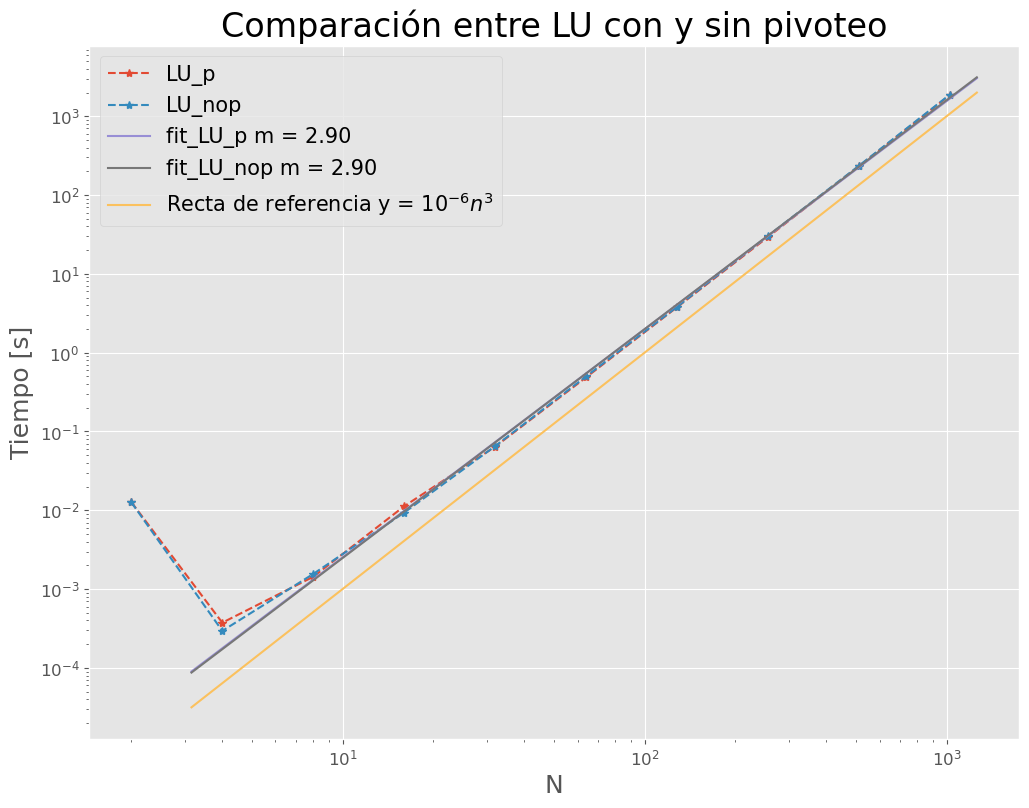

In [10]:
k = np.logspace(.5,3.1,50,base=10)
plt.loglog(n_LU_p,t_LU_p,'--*',label='LU_p')

plt.loglog(n_LU_nop,t_LU_nop,'--*',label='LU_nop')

plt.plot(k,np.exp(z_LU_p(np.log(k))),label=f'fit_LU_p m = {p_LU_nop[0]:.2f}')
plt.plot(k,np.exp(z_LU_nop(np.log(k))),label=f'fit_LU_nop m = {p_LU_nop[0]:.2f}')
plt.plot(k,10**-6*k**3, label='Recta de referencia y = $10^{-6}n^3$')
# plt.plot(k,np.exp(z_pcg(np.log(k))),label='fit_pcg m = 1.34')

plt.title('Comparación entre LU con y sin pivoteo')
plt.xlabel('N')
plt.ylabel('Tiempo [s]')
plt.legend()

# plt.savefig(
#     "graficos/LU-LUp.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
#     dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
#     bbox_inches="tight",  # recorta bordes en blanco innecesarios
#     pad_inches=0.05,   # un poquito de espacio alrededor
#     transparent=False, # True si querés fondo transparente
#     facecolor="white"  # color de fondo (se aplica si transparent=False)
# )


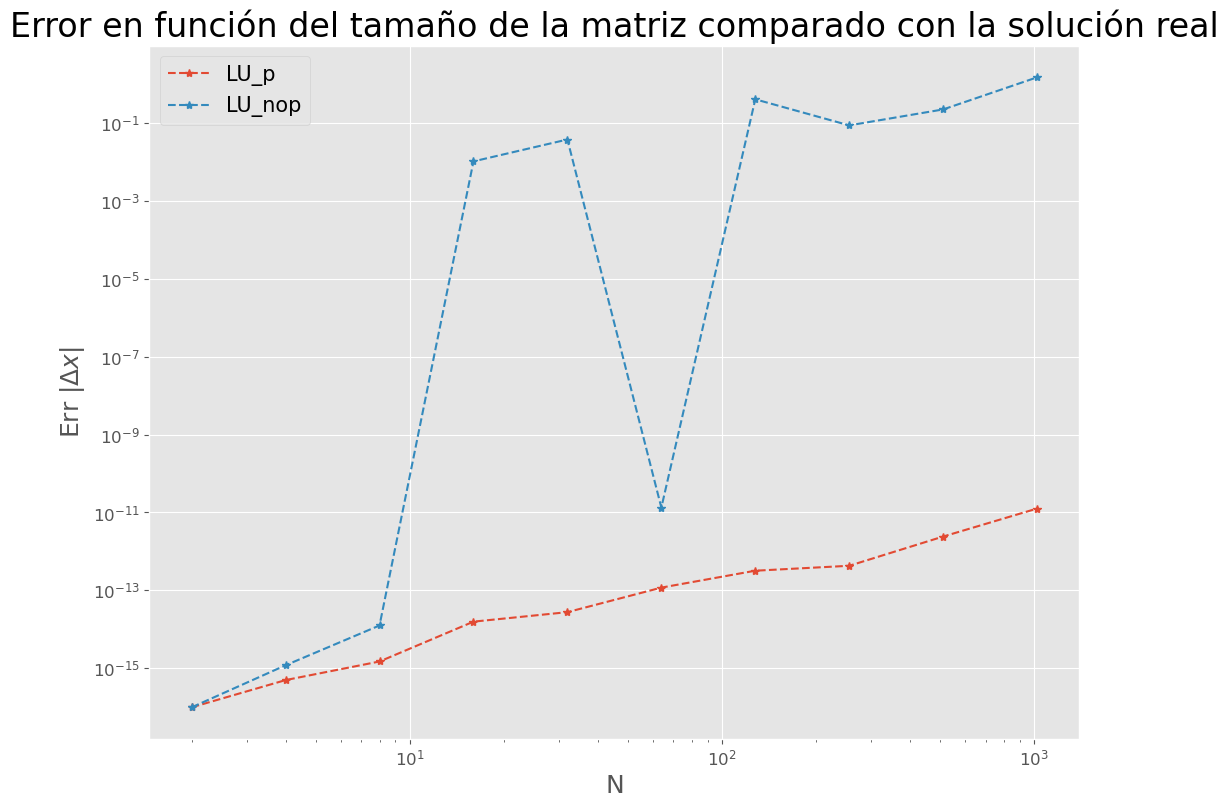

In [11]:
# plt.loglog(n_LU_p_2,err_LU_p_2,'--*',label='LU_p_2')
plt.loglog(n_LU_p,err_LU_p,'--*',label='LU_p')


plt.loglog(n_LU_nop,err_LU_nop,'--*',label='LU_nop')

# plt.loglog(pcg['N'],pcg['err'],'--*',label='pcg')

plt.title('Error en función del tamaño de la matriz comparado con la solución real')
plt.xlabel('N')
plt.ylabel('Err $|\\Delta x |$')
plt.legend()



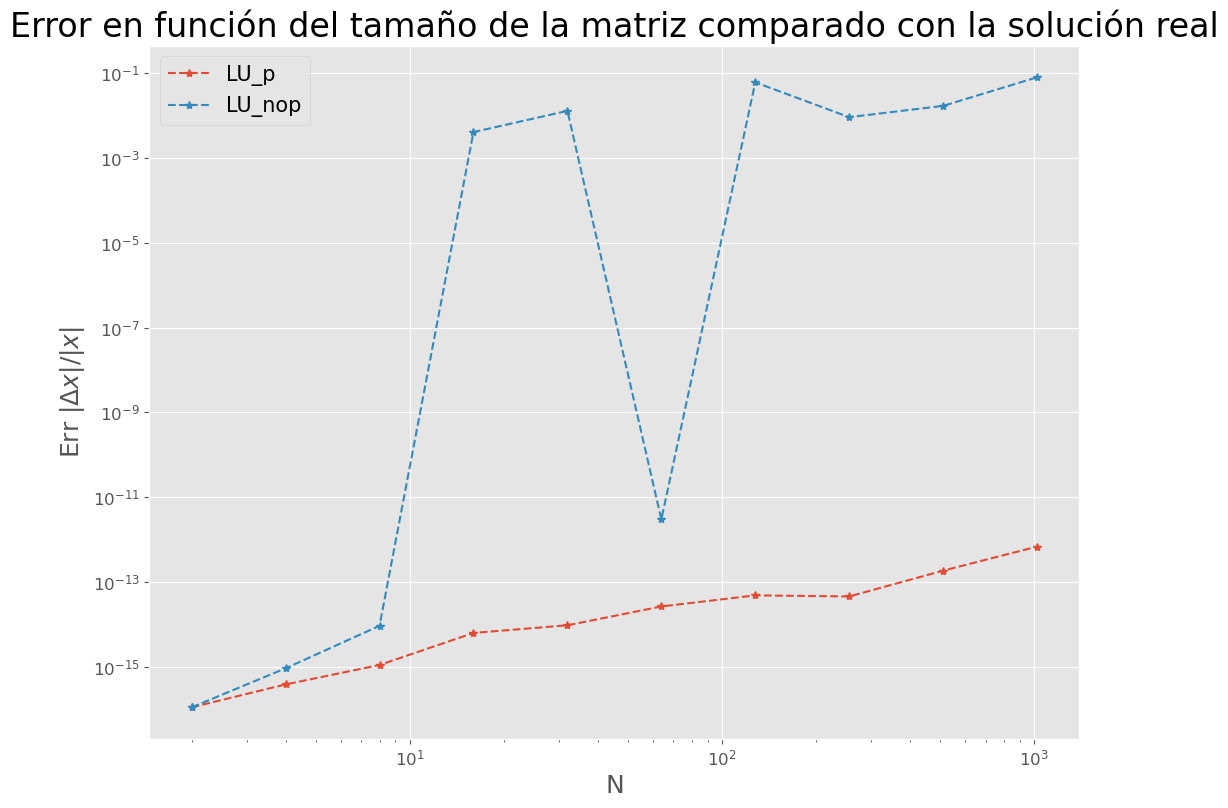

In [22]:
# plt.loglog(n_LU_p_2,err_LU_p_2/x_LU_p_2,'--*',label='LU_p_2')

plt.loglog(n_LU_p,err_LU_p/x_LU_p,'--*',label='LU_p')

plt.loglog(n_LU_nop,err_LU_nop/x_LU_nop,'--*',label='LU_nop')
# plt.loglog(pcg['N'],pcg['err']/pcg['norm_x'],'--*',label='pcg')


plt.title('Error en función del tamaño de la matriz comparado con la solución real')
plt.xlabel('N')
plt.ylabel('Err $|\\Delta x |/|x|$')
plt.legend()

plt.savefig(
    "graficos/LU-err_rel.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # True si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)


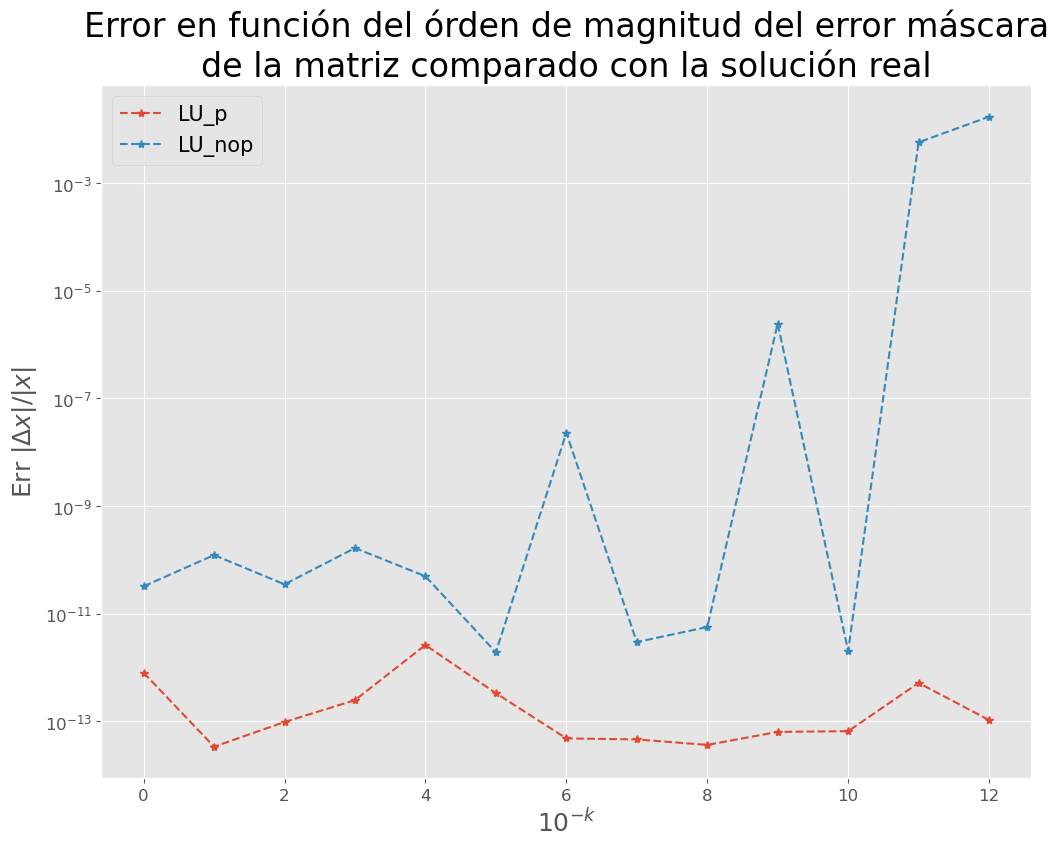

In [23]:
# plt.loglog(n_LU_p_2,err_LU_p_2/x_LU_p_2,'--*',label='LU_p_2')

plt.semilogy(factor_k_LU_p,
             factor_err_LU_p/factor_x_LU_p,
             '--*', label='LU_p')

plt.semilogy(factor_k_LU_nop,
             factor_err_LU_nop/factor_x_LU_nop,
             '--*', label='LU_nop')

plt.title('Error en función del órden de magnitud del error máscara\nde la matriz comparado con la solución real')
plt.xlabel('$10^{-k}$')
plt.ylabel('Err $|\\Delta x|/|x|$')
plt.legend()
plt.savefig(
    "graficos/LU-err_k.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # True si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)
